In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
X = np.array([
    [1, 2],
    [2, 1],
    [3, 3]
], dtype=float)

In [4]:
y = np.array([5, 6, 10], dtype=float)

In [5]:
w=np.zeros(X.shape[1])
alpha=0.01
iterations=20
m=X.shape[0]

In [6]:
for i in range(iterations):
    y_pred=X.dot(w)
    error=y-y_pred
    gradient=-(2/m) * X.T.dot(error)
    w=w-alpha*gradient
    print(f"Iteration {i+1}: w = {w}, loss = {np.mean(error**2):.4f}")



Iteration 1: w = [0.31333333 0.30666667], loss = 53.6667
Iteration 2: w = [0.57084444 0.55755556], loss = 36.1743
Iteration 3: w = [0.78257748 0.76271052], loss = 24.4117
Iteration 4: w = [0.95676867 0.93036749], loss = 16.5018
Iteration 5: w = [1.10017175 1.0672799 ], loss = 11.1825
Iteration 6: w = [1.21832479 1.17898556], loss = 7.6052
Iteration 7: w = [1.31576906 1.27002543], loss = 5.1991
Iteration 8: w = [1.39622841 1.34412307], loss = 3.5806
Iteration 9: w = [1.46275643 1.40433179], loss = 2.4917
Iteration 10: w = [1.51785707 1.45315526], loss = 1.7589
Iteration 11: w = [1.56358362 1.49264649], loss = 1.2655
Iteration 12: w = [1.60161979 1.52448891], loss = 0.9332
Iteration 13: w = [1.63334624 1.55006289], loss = 0.7091
Iteration 14: w = [1.65989514 1.57050035], loss = 0.5578
Iteration 15: w = [1.68219489 1.5867294 ], loss = 0.4555
Iteration 16: w = [1.70100682 1.5995111 ], loss = 0.3861
Iteration 17: w = [1.71695522 1.60946947], loss = 0.3389
Iteration 18: w = [1.73055205 1.617

In [7]:
print("\nFinal weights:", w)


Final weights: [1.75229472 1.62707742]


In [8]:
import matplotlib.pyplot as plt

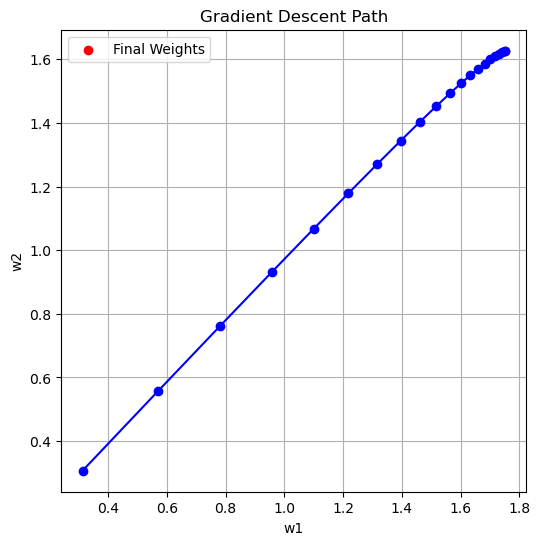

In [9]:
# using ai for fast coding

import numpy as np

import matplotlib.pyplot as plt

# --- Dataset ---
X = np.array([[1,2],[2,1],[3,3]], dtype=float)
y = np.array([5,6,10], dtype=float)

# --- Gradient Descent setup ---
w = np.zeros(X.shape[1])
alpha = 0.01
iterations = 20
m = X.shape[0]

# --- Store weights for plotting ---
weights_history = []

for i in range(iterations):
    y_pred = X.dot(w)
    error = y - y_pred
    gradient = -(2/m) * X.T.dot(error)
    w = w - alpha * gradient
    weights_history.append(w.copy())  # store weights

weights_history = np.array(weights_history)

# --- Plotting gradient descent path ---
plt.figure(figsize=(6,6))
plt.plot(weights_history[:,0], weights_history[:,1], marker='o', color='blue')
plt.scatter(weights_history[-1,0], weights_history[-1,1], color='red', label='Final Weights')
plt.xlabel('w1')
plt.ylabel('w2')
plt.title('Gradient Descent Path')
plt.grid(True)
plt.legend()
plt.show()

## New program

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
df=pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


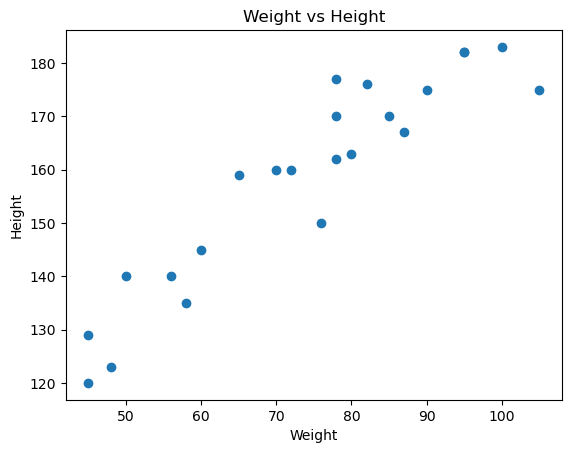

In [12]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Weight vs Height')
plt.show()

In [13]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


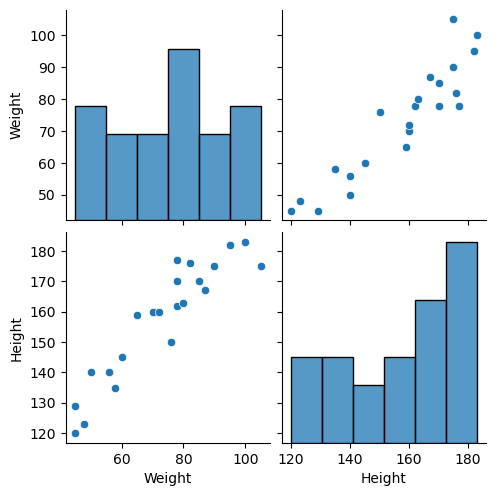

In [14]:
import seaborn as sns
pairplot=sns.pairplot(df)
plt.show()


In [20]:
## Independent and depenedent feature 
## independent feature should be in data frame or 2 dimensional array
X=df[['Weight']]
Y=df['Height']



In [22]:
np.array(Y).shape

(23,)

In [29]:
## Train Test split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

In [30]:
X_train.shape

(17, 1)

In [31]:
from sklearn.preprocessing import StandardScaler



In [33]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [34]:
X_test=scaler.transform(X_test)

In [35]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [37]:
## apply Simple linear regression
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)


In [38]:
regression.fit(X_train,Y_train)


LinearRegression(n_jobs=-1)

In [39]:
print("Coefficient or slope:",regression.coef_)
print("Intercept:",regression.intercept_)


Coefficient or slope: [17.2982057]
Intercept: 156.47058823529412


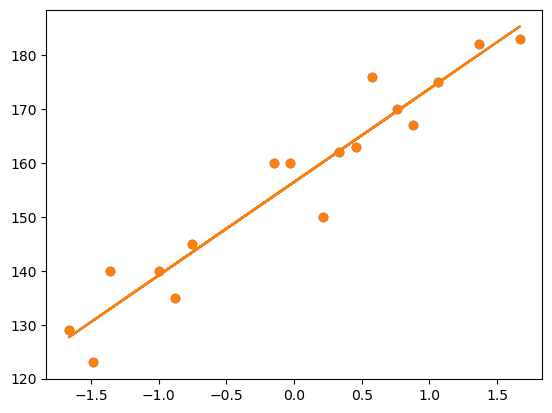

In [41]:
plt.scatter(X_train,Y_train)
plt.plot(X_train,regression.predict(X_train))
plt.show()

In [42]:
y_pred=regression.predict(X_test)


In [43]:
from sklearn.metrics import mean_absolute_error,mean_squared_error


In [45]:
mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


In [46]:
from sklearn.metrics import r2_score


In [47]:
score=r2_score(Y_test,y_pred)
print(score)

0.7360826717981276


In [48]:
#display adjusted R-squared
1 - (1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

0.6701033397476595

In [49]:
import statsmodels.api as sm


In [50]:
model=sm.OLS(Y_train,X_train).fit()

In [51]:
prediction=model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [52]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Tue, 24 Feb 2026   Prob (F-statistic):                       0.664
Time:                        01:30:45   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)
